# 🌐 LangGraph 기반 EXA 웹 검색 에이전트 실습

이번 실습에서는 **EXA Search API**를 활용한 웹 검색 에이전트를 **3가지 방식**으로 구현해보며, 각 방식의 특징과 장단점을 비교합니다.

> 📢 **EXA Search란?**
> 
> EXA는 AI 애플리케이션을 위해 설계된 **차세대 웹 검색 API**입니다.
> - **신경망 기반 검색**: 키워드가 아닌 의미 기반 검색
> - **실시간 웹 데이터**: 최신 정보 검색 가능
> - **고품질 결과**: SEO 스팸을 필터링한 깨끗한 결과

### 🎯 학습 목표
1. LangChain의 `create_agent`로 간단한 에이전트 구현
2. LangGraph의 StateGraph로 세밀한 Tool Call Routing 구현
4. 각 방식의 장단점 비교 및 선택 기준 이해


## 📋 목차

### Part A: LangChain create_agent (기본)
1. [환경 설정](#1-환경-설정)
2. [EXA Search Tool 생성](#2-exa-search-tool-생성)
3. [LangChain create_agent](#3-langchain-create_agent)

### Part B: LangGraph Tool Call Routing (심화)
4. [LangGraph 상태 정의](#4-langgraph-상태-정의)
5. [그래프 노드 및 엣지 구현](#5-그래프-노드-및-엣지-구현)
6. [Tool Call Routing 에이전트 실행](#6-tool-call-routing-에이전트-실행)


---
# 🔧 Part A: LangChain create_agent (기본)

## 1. 환경 설정

먼저 필요한 패키지들을 설치하고 환경을 구성합니다.


In [4]:
# 필요한 패키지 설치
# !pip install -qU langchain langchain-openai langgraph langchain-exa exa-py python-dotenv
!pip install -qU langchain-exa exa-py



[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: C:\Users\rkfka\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [7]:
# 환경 변수 설정
import os
from dotenv import load_dotenv

load_dotenv()

# API 키 설정
# if not os.getenv("OPENAI_API_KEY"):
#     os.environ["OPENAI_API_KEY"] = "your-openai-api-key"

OPENROUTER_API_KEY = os.environ["OPENROUTER_API_KEY"]

# # EXA API 키 (https://exa.ai 에서 발급)
# if not os.getenv("EXA_API_KEY"):
#     os.environ["EXA_API_KEY"] = "your-exa-api-key"

EXA_API_KEY = os.environ["EXA_API_KEY"]

print("✅ 환경 설정 완료!")


✅ 환경 설정 완료!


---
## 2. EXA Search Tool 생성

EXA의 검색 기능을 LangChain Tool로 래핑합니다.


In [3]:
from langchain_core.tools import tool
from exa_py import Exa

# EXA 클라이언트 초기화
exa_client = Exa(api_key=os.environ["EXA_API_KEY"])

@tool
def exa_web_search(query: str) -> str:
    """
    EXA를 사용하여 웹에서 최신 정보를 검색합니다.
    최신 뉴스, 기술 트렌드, 연구 논문 등을 검색할 때 사용하세요.
    
    Args:
        query: 검색할 질문이나 키워드
    """ 
    results = exa_client.search_and_contents(
        query=query,
        num_results=5,
        text={"max_characters": 1000},
        highlights={"num_sentences": 3}
    )
    
    output = []
    for result in results.results:
        output.append(f"**Title**: {result.title}")
        output.append(f"**URL**: {result.url}")
        if result.highlights:
            output.append(f"**Highlights**: {' '.join(result.highlights)}")
        output.append("---")
    
    return "\n".join(output)

print("✅ EXA Search Tool 생성 완료!")


✅ EXA Search Tool 생성 완료!


In [5]:
# EXA 검색 테스트
test_result = exa_web_search.invoke({"query": "LangGraph agent framework"})
print("🔍 EXA 검색 테스트:\n")
print(test_result[:1000] + "..." if len(test_result) > 1000 else test_result)


🔍 EXA 검색 테스트:

**Title**: LangGraph overview - Docs by LangChain
**URL**: https://docs.langchain.com/langgraph
**Highlights**: # LangGraph overview
[...]
> Gain control with LangGraph to design agents that reliably handle complex tasks
[...]
Trusted by companies shaping the future of agents-- including Klarna, Uber, J.P. Morgan, and more-- LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents.
[...]
LangGraph is very low-level, and focused entirely on agent orchestration. Before using LangGraph, we recommend you familiarize yourself with some of the components used to build agents, starting with models and tools.
[...]
We will commonly use LangChain components throughout the documentation to integrate models and tools, but you don't need to use LangChain to use LangGraph. If you are just getting started with agents or want a higher-level abstraction, we recommend you use Lang
---
**Title**: LangGraph: Agent Orch

---
## 3. LangChain create_agent

LangChain의 **`create_agent`**는 ReAct(Reasoning + Acting) 패턴을 구현한 에이전트를 생성합니다.



agent = create_agent(llm, tools, prompt)
```


In [8]:
from pyexpat import model

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

# LLM 설정
# llm = ChatOpenAI(model="gpt-5-mini", temperature=0)

llm = ChatOpenAI(
    model       = "openai/gpt-oss-120b:free",
    api_key     = OPENROUTER_API_KEY,
    base_url    = "https://openrouter.ai/api/v1" # api_base → base_url
)

# 도구 리스트
tools = [exa_web_search]

# 에이전트 생성
langchain_agent = create_agent(llm, tools)

print("✅ LangChain ReAct 에이전트 생성 완료!")


✅ LangChain ReAct 에이전트 생성 완료!


In [9]:
from datetime import datetime
today = datetime.now().strftime("%Y년 %m월 %d일")

# LangChain 에이전트 테스트
test_question = "AI 에이전트 프레임워크 트렌드를 알려줘"

print(f"💬 질문: {test_question}")
print("=" * 50)


for chunk in langchain_agent.stream(  
    {"messages": [
        {"role": "system", "content": f"You are a helpful AI assistant with web search capabilities. Today is {today}"},
        {"role": "user", "content": test_question}]},
    stream_mode="updates"):
    for step, data in chunk.items():
        print(f"step: {step}")
        print(f"content: {data['messages'][-1].content_blocks}")

💬 질문: AI 에이전트 프레임워크 트렌드를 알려줘
step: model
content: [{'type': 'tool_call', 'name': 'exa_web_search', 'args': {'query': '2025 2026 AI agent framework trends'}, 'id': 'chatcmpl-tool-80b535e337d625ee'}]
step: tools
content: [{'type': 'text', 'text': '**Title**: The State of AI Agent Frameworks in 2026 | Fordel Studios\n**URL**: https://fordelstudios.com/research/state-of-ai-agent-frameworks-2026\n**Highlights**: The agent framework landscape consolidated fast in 2025. LangGraph, AutoGen, and CrewAI each won different segments — here is what actually separates them and how to pick for your use case.\n[...]\nEighteen months ago, every engineering team building agent systems was rolling their own orchestration layer. The frameworks existed but none had earned trust at production scale. That has changed. By early 2026, three frameworks have emerged with real production deployments behind them, and the selection decision has become less philosophical and more operational.\n[...]\nThis is not a f

In [16]:
print(chunk['model']['messages'][-1].content_blocks[0]['text'])

## 2026 AI Agent‑Framework 트렌드 요약  
*(2025‑2026년 사이에 발표된 여러 산업 보고서·블로그·컨설팅 자료를 종합)*  

| 구분 | 핵심 트렌드 | 왜 중요한가? | 주요 기술·툴 |
|------|------------|--------------|-------------|
| **1. 에이전트가 ‘디지털 조립 라인’이 된다** | 단일 프롬프트 → 복합 워크플로우(다단계, 다에이전트, 인간‑인간‑AI 협업) | 기업은 “업무 전체를 자동화”하는 수준으로 전환하고 있음. 비용‑시간 절감, SLA 향상이 바로 비즈니스 KPI와 직결. | LangGraph, CrewAI, AutoGen, OpenAI Agents SDK, Claude Agent SDK |
| **2. 운영·생산성을 위한 ‘오케스트레이션 레이어’ 표준화** | 프레임워크가 **툴 호출, 상태·메모리 관리, 오류 복구, 모니터링** 를 기본 제공 | 2024‑25년 “핸드코딩 오케스트레이션”이 장애 원인 70% 이상 차지했음. 표준 레이어 덕분에 2 am ‘핵심 에이전트 다운’ 상황이 크게 감소. | LangGraph (그래프‑기반 상태 관리), CrewAI (프로젝트‑레벨 플랜), AutoGen (멀티‑에이전트 협상 프로토콜) |
| **3. “장기 기억·지속 실행”(Durable Agent State)** | 에이전트가 재시작·스케일아웃해도 **컨텍스트와 학습 결과**를 보존 | 금융·보안·제조와 같이 “시계열·규제”가 중요한 도메인에서 필수. | Letta, Memory‑LLM, Chroma DB‑연동, LangGraph ‘Snapshot API’ |
| **4. 자기‑개선 & 자동‑리파인먼트** | 에이전트가 실행 로그·피드백을 분석해 **프롬프트·플랜을 스스로 튜닝** | 비용 절감(재시도·인간 검토 감소) + 품질 향상(오류 전이 감소). | AutoGen ‘Self‑Reflection’, CrewAI ‘Iterative Evaluation’, OpenH

### 💡 LangChain create_agent 정리

**장점:**
- 빠른 프로토타이핑에 적합

**한계:**
- 복잡한 워크플로우 구현 어려움
- 조건부 분기, 루프 등 세밀한 제어 제한
- 상태 관리가 명시적이지 않음

👉 **더 복잡한 에이전트가 필요하다면? → LangGraph로!**


---
# 🔄 Part B: LangGraph Tool Call Routing (심화)

## 4. LangGraph 상태 정의

LangGraph는 **명시적인 상태 관리**와 **그래프 기반 워크플로우**를 제공합니다.

### 그래프 구조:
```
START → call_model → [tool_calls 있음?]
                       ├─ Yes → tools → call_model
                       └─ No → END
```

### 핵심 개념:
- **State**: 그래프 전체에서 공유되는 상태
- **Node**: 상태를 변환하는 함수
- **Edge**: 노드 간 연결 (조건부 가능)
- **ToolNode**: 도구 실행을 담당하는 prebuilt 노드


In [17]:
from typing import Annotated, Literal
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage

# MessagesState: 메시지 리스트를 자동으로 관리하는 내장 상태
# messages 필드가 자동으로 누적됨

print("📊 MessagesState 구조:")
print("  - messages: Annotated[list, add_messages]")
print("  - 메시지가 자동으로 리스트에 추가됨")


📊 MessagesState 구조:
  - messages: Annotated[list, add_messages]
  - 메시지가 자동으로 리스트에 추가됨


---
## 5. 그래프 노드 및 엣지 구현

각 노드와 조건부 라우팅 로직을 구현합니다.


In [18]:
from datetime import datetime
today = datetime.now().strftime("%Y년 %m월 %d일")

# LLM에 도구 바인딩
llm_with_tools = llm.bind_tools(tools)

# 1. 모델 호출 노드
def call_model(state: MessagesState):
    """LLM을 호출하여 응답 또는 도구 호출 결정"""
    print("---CALL MODEL---")
    
    # 시스템 프롬프트
    system_message = {
        "role": "system",
        "content": f"""You are a helpful AI assistant with web search capabilities. Today is {today}. 
Use exa_web_search for questions requiring current information with citations. Please always respond in Korean."""
    }
    
    messages = [system_message] + state["messages"]
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response]}

# 2. 조건부 라우팅 함수
def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """도구 호출 필요 여부 판단"""
    last_message = state["messages"][-1]
    
    # tool_calls가 있으면 도구 실행
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        print("---ROUTING TO TOOLS---")
        return "tools"
    
    # 없으면 종료
    print("---ROUTING TO END---")
    return "__end__"

# 3. ToolNode 생성 (도구 실행 담당)
tool_node = ToolNode(tools)

print("✅ 노드 및 라우팅 함수 정의 완료!")


✅ 노드 및 라우팅 함수 정의 완료!


In [19]:
# 그래프 조립
workflow = StateGraph(MessagesState)

# 노드 추가
workflow.add_node("call_model", call_model)
workflow.add_node("tools", tool_node)

# 엣지 연결
workflow.add_edge(START, "call_model")

# 조건부 엣지: call_model 후 도구 호출 여부에 따라 분기
workflow.add_conditional_edges(
    "call_model",
    should_continue,
    {
        "tools": "tools",
        "__end__": END
    }
)

# 도구 실행 후 다시 모델 호출
workflow.add_edge("tools", "call_model")

# 그래프 컴파일
langgraph_agent = workflow.compile()

print("✅ LangGraph Tool Call Routing 에이전트 컴파일 완료!")


✅ LangGraph Tool Call Routing 에이전트 컴파일 완료!


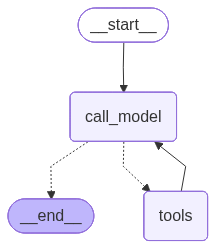

In [20]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"시각화 오류: {e}")
    print("그래프 구조: START → call_model → [tools/END] → call_model → END")


---
## 6. Tool Call Routing 에이전트 실행

구축한 LangGraph 에이전트를 테스트합니다.


In [21]:
# 테스트 1: 일반 대화 (도구 호출 없음)
test1 = "안녕하세요!"

print(f"💬 질문: {test1}")
print("=" * 50)

result = langgraph_agent.invoke({"messages": [{"role": "user", "content": test1}]})
print(f"\n🤖 답변:\n{result['messages'][-1].content}")


💬 질문: 안녕하세요!
---CALL MODEL---
---ROUTING TO END---

🤖 답변:
안녕하세요! 무엇을 도와드릴까요? 😊


In [22]:
# 테스트 2: 웹 검색 필요한 질문
test2 = "LangGraph와 CrewAI의 차이점을 알려줘"

print(f"💬 질문: {test2}")
print("=" * 50)

result = langgraph_agent.invoke({"messages": [{"role": "user", "content": test2}]})
print(f"\n🤖 답변:\n{result['messages'][-1].content}")


💬 질문: LangGraph와 CrewAI의 차이점을 알려줘
---CALL MODEL---
---ROUTING TO TOOLS---
---CALL MODEL---
---ROUTING TO END---

🤖 답변:
## LangGraph와 CrewAI (2026년 기준) 주요 차이점

| 구분 | LangGraph | CrewAI |
|------|-----------|--------|
| **핵심 사고 모델** | **그래프‑기반**<br> · `StateGraph`‑다이어그램, 노드·에지·전이 형태<br> · 워크플로우를 명시적 유한 상태 머신처럼 설계 | **팀‑기반** (역할·태스크) <br> · `Agent`, `Task`, `Crew` 개념<br> · “역할‑목표‑할당” 방식의 흐름을 데코레이터로 선언 |
| **상태 관리** | `State` 딕셔너리를 노드 사이에 공유 → 자동 체크포인트, 직렬화, 재시작 지원 | `Context` 객체(또는 전역 변수) → `Crew` 내부에서 자동 전달, 별도 체크포인트 기능은 없지만 `Flow`‑레벨에서 `@step`‑데코레이터로 상태를 명시 가능 |
| **조건·분기** | Edge에 **조건 함수**를 지정해 동적 라우팅 (예: `if state["step"] > 2: …`) | `@task`‑데코레이터에 `condition=` 옵션 또는 `crew.run_until()` 로 흐름 제어. 보통 “if‑else”를 파이썬 로직 안에 넣는 형태 |
| **오케스트레이션 방식** | **명시적 그래프**<br> · `graph.add_edge("A", "B")` 등으로 모든 전이 선언<br> · 복잡한 비순차적 흐름에 강점 | **암시적 흐름**<br> · 함수 체이닝, `crew.kickoff()` → 자동으로 역할·태스크 순서 실행<br> · 단순 순차·반복 작업에 문법 설탕 제공 |
| **사용자 경험(코드 가독성)** | 그래프 정의가 다소 장황<br> · 대규모 DAG에서는 보기 좋지만 작은 흐름엔 B

In [23]:
# 스트리밍으로 실행 과정 확인
test3 = "OpenAI의 최신 모델 소식을 알려줘"

print(f"💬 질문: {test3}")
print("=" * 50)
print("\n🔄 실행 과정:")

for chunk in langgraph_agent.stream({"messages": [{"role": "user", "content": test3}]}):
    for node_name, value in chunk.items():
        print(f"\n📍 [{node_name}] 노드 실행")
        
        if "messages" in value and value["messages"]:
            last_msg = value["messages"][-1]
            
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                for tc in last_msg.tool_calls:
                    print(f"   🔧 Tool: {tc['name']}")
            elif hasattr(last_msg, 'content') and last_msg.content:
                content = str(last_msg.content)
                if node_name == "call_model" and not (hasattr(last_msg, 'tool_calls') and last_msg.tool_calls):
                    print(f"\n🤖 최종 답변:\n{content}")


💬 질문: OpenAI의 최신 모델 소식을 알려줘

🔄 실행 과정:
---CALL MODEL---
---ROUTING TO TOOLS---

📍 [call_model] 노드 실행
   🔧 Tool: exa_web_search

📍 [tools] 노드 실행
---CALL MODEL---
---ROUTING TO END---

📍 [call_model] 노드 실행

🤖 최종 답변:
## OpenAI 최신 모델 (2026년 기준)

| 모델 | 발표일 | 주요 특징 | 적용 분야·특징 | 비고 |
|------|--------|-----------|----------------|------|
| **GPT‑5.5** | 2026‑04‑23 | - 현재 가장 **똑똑하고 빠른** 모델<br>- 100만 토큰까지 지원하는 초대형 컨텍스트<br>- 멀티모달(텍스트·이미지·음성) 완전 통합<br>- 코딩·연구·데이터 분석 등 복합 작업에 최적화<br>- 기존 GPT‑5.4 대비 **추론 효율 2×** 향상, 비용 30 % 절감 | 고급 연구, 대규모 코드베이스 분석, 약물·재료 설계, 복합 에이전트 워크플로 | “GPT‑5.5 System Card”와 함께 발표. 현재 ChatGPT Plus/Enterprise, API(`gpt‑5.5`)에서 제공 시작 |
| **GPT‑5.4** | 2026‑03‑05 | - “Thinking” 시리즈 핵심 모델<br>- 1 M 토큰 컨텍스트, **코딩·에이전트·멀티모달** 강점<br>- Codex 기반 코드 능력 통합, 기본 컴퓨터 사용(스크린샷·클릭·앱 제어) 지원<br>- 비용·지연 시간 최적화, 토큰 효율성 최고 | 전문 작업(스프레드시트·프레젠테이션·문서 자동화), 복합 에이전트, 장시간 프로젝트 관리 | API 명칭 `gpt‑5.4` / `gpt‑5.4‑pro` (고성능 버전) |
| **GPT‑5.4 mini** | 2026‑03‑17 | - GPT‑5.4 기반 **소형** 모델<br>- 속도 2× 이상 빠르면서도 대부분의 

### 💡 LangGraph Tool Call Routing 정리

**장점:**
- **완전한 제어**: 모든 노드와 엣지를 직접 정의
- **상태 관리**: 명시적인 상태 추적 및 디버깅
- **확장성**: 복잡한 워크플로우, 조건부 분기, 루프 구현 가능
- **시각화**: 그래프 구조를 시각적으로 확인

**한계:**
- 더 많은 코드 작성 필요
- 간단한 에이전트에는 과도할 수 있음

👉 **더 간결하게 만들고 싶다면? → LangGraph prebuilt create_agent!**


## 🎯 Streaming 실습

LangGraph는 실시간 업데이트를 제공하는 스트리밍 시스템을 구현합니다.

**주요 Stream Modes:**
- `values`: 각 단계 후 전체 상태 스트리밍
- `updates`: 각 단계 후 상태 업데이트만 스트리밍
- `messages`: LLM 토큰 스트리밍
- `custom`: 사용자 정의 데이터 스트리밍
- `debug`: 상세한 디버깅 정보 스트리밍

In [24]:
# messages 모드: LLM 토큰 실시간 스트리밍
print("=" * 60)
print("📊 Stream Mode: messages (LLM 토큰 스트리밍)")
print("=" * 60)

test_query = "OpenAI의 최신 모델 소식을 알려줘"

print(f"\n💬 질문: {test_query}\n")
print("🤖 답변: ", end="", flush=True)

for message_chunk, metadata in langgraph_agent.stream(
    {"messages": [{"role": "user", "content": test_query}]},
    stream_mode="messages"
):
    # LLM 토큰만 출력 (tool call은 제외)
    if message_chunk.content:
        print(message_chunk.content, end="", flush=True)

print("\n")

📊 Stream Mode: messages (LLM 토큰 스트리밍)

💬 질문: OpenAI의 최신 모델 소식을 알려줘

🤖 답변: ---CALL MODEL---
---ROUTING TO TOOLS---
**Title**: 모델 출시 노트 | OpenAI Help Center
**URL**: https://help.openai.com/ko-kr/articles/9624314-model-release-notes
**Highlights**: ## ChatGPT의 GPT-5.4 mini (2026년 3월 18일)
[...]
ChatGPT에서 GPT-5.4 mini를 출시합니다. GPT-5.4 mini는 + 메뉴의 “Thinking” 기능을 통해 Free 및 Go 사용자가 이용할 수 있습니다. 그 외 모든 사용자에게는 GPT-5.4 Thinking의 요청 한도 도달 시 대체(폴백)로 GPT-5.4 mini가 제공됩니다.Plus, Pro 및 기타 유료 사용자의 경우, 요청 한도에 도달하면 GPT-5.4 Thinking의 대체로 GPT-5.4 mini가 사용되어 사용량이 많은 상황에서도 추론 기능에 계속 접근할 수 있도록 돕습니다. Enterprise 고객은 원할 경우 Auto 라우팅의 기본값을 GPT-5.4 mini로 설정하는 옵션을 유지합니다.GPT-5.4 mini는 모델 선택기에서 선택 가능한 모델로 표시되지 않으며, GPT-5 Thinking mini는 30일 후 선택 가능한 옵션에서 제외됩니다. 자세한 내용은블로그 게시물을 참고하세요.
[...]
## GPT-5.3 Instant 업데이트 (2026년 3월 16일)
[...]
후속 응답의 톤을 개선하고 응답에서 티저(낚시) 스타일의 표현을 줄이는 GPT-5.3 Instant 업데이트를 출시합니다(예: “원하신다면…”, “믿기 힘들겠지만…”, “제가 이 세 가지를 말씀드릴게요…”).
[...]
## GPT-5.1 모델 지원 종료 (2026년 3월 11일)
[...]
2026년 3월 11일부터 ChatGPT에서 GP